In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import re
import os
import glob
import sys
from tqdm import tqdm
import datetime
import gc
import numpy as np
import tensorflow as tf

In [118]:
config = {
    'project_path': 'drive/MyDrive/author-handwriting-recog',
    'dataset': 'complete_dataset_20260122-142244.tar.gz',
    "model_type": "pair",
    'authors': 100,
    'authors_range': range(100),
    'input_shape': (113, 113, 1),
    'embedding_dim': 512,
    'epochs': 25,
    'seed': 42,
    'batch_size': {
        'train': 64,
        'validation': 32,
        'test': 16
    }
}

In [4]:
sys.path.insert(0, config['project_path'])

In [5]:
sys.path

['drive/MyDrive/author-handwriting-recog',
 '/content',
 '/env/python',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/usr/local/lib/python3.12/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/IPython/extensions',
 '/root/.ipython']

In [6]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 123.7 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=0fe2b60e82b739c95d7a2318d9962e30933121506607e46a2b72c121ba74d34c
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [7]:
from src.io.exceptions import DeserializationError
from src.io.logging import LoggerFactory
from src import SelectiveDataLoader
from src.io import load

In [8]:
dataset_path = f"{config['project_path']}/data/datasets/{config['dataset']}"

In [9]:
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

In [10]:
logger = LoggerFactory.get_notebook_logger("code_1", log_dir=f"./logs_{current_time}")

In [11]:
!tar -xzf {dataset_path} -C ./

In [12]:
loader = SelectiveDataLoader(
        dataset_path="./complete_dataset_20260122-142244.zarr",
        load_fn=load
        )

11:38:14 - ZarrSerializer - INFO - Initialized with blosc compression (level 5)
11:38:14 - ZarrSerializer - INFO - ======================================================================
11:38:14 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
11:38:14 - ZarrSerializer - INFO - ======================================================================
11:38:15 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
11:38:15 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
11:38:15 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
11:38:15 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
11:38:15 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
11:38:15 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
11:38:15 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
11:38:15 - ZarrSerializer - INFO - ======================

In [13]:
from src.datasets import SubsetBuilder, PairGenerator, DataGenerator, TripletGenerator

In [14]:
subset_builder = SubsetBuilder(
    loader=loader,
)

In [15]:
subset = subset_builder.build(
    authors_range=config['authors_range'],
    show_progress_bar=True,
)

11:38:15 - ZarrSerializer - INFO - ======================================================================
11:38:15 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
11:38:15 - ZarrSerializer - INFO - ======================================================================
11:38:15 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
11:38:15 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
11:38:15 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
11:38:15 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
11:38:15 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
11:38:15 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
11:38:15 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
11:38:15 - ZarrSerializer - INFO - ======================================================================
11:38:15 - ZarrSerializer - INF

Loading train: 100%|██████████| 100/100 [00:34<00:00,  2.89it/s]


11:38:53 - ZarrSerializer - INFO - ======================================================================
11:38:53 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
11:38:53 - ZarrSerializer - INFO - ======================================================================
11:38:53 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
11:38:53 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
11:38:53 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
11:38:53 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
11:38:53 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
11:38:53 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
11:38:53 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
11:38:53 - ZarrSerializer - INFO - ======================================================================
11:38:53 - ZarrSerializer - INF

Loading validation: 100%|██████████| 100/100 [00:04<00:00, 24.17it/s]


11:38:58 - ZarrSerializer - INFO - ======================================================================
11:38:58 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
11:38:58 - ZarrSerializer - INFO - ======================================================================
11:38:58 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
11:38:58 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
11:38:58 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
11:38:58 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
11:38:58 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
11:38:58 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
11:38:58 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
11:38:58 - ZarrSerializer - INFO - ======================================================================
11:38:58 - ZarrSerializer - INF

Loading test: 100%|██████████| 100/100 [00:01<00:00, 83.58it/s]


In [119]:
train_pair_gen = PairGenerator(
    data=subset.splits['train'],
    batch_size=config['batch_size']['train'],
    target_size=config['input_shape'][:2],
    shuffle=True,
    use_augmentation=True,
    seed=config['seed']
)

In [120]:
val_pair_gen = PairGenerator(
    data=subset.splits['validation'],
    batch_size=config['batch_size']['validation'],
    target_size=config['input_shape'][:2],
    use_augmentation=False,
    shuffle=False,
    seed=config['seed']
)

In [121]:
test_pair_gen = PairGenerator(
    data=subset.splits['test'],
    batch_size=config['batch_size']['test'],
    target_size=config['input_shape'][:2],
    use_augmentation=False,
    shuffle=False,
    seed=config['seed']
)

In [122]:
len(train_pair_gen), len(val_pair_gen), len(test_pair_gen)

(4851, 1575, 783)

In [123]:
logger.info(f"Train samples: {train_pair_gen.num_patches}")
logger.info(f"Validation samples: {val_pair_gen.num_patches}")
logger.info(f"Test samples: {test_pair_gen.num_patches}")
logger.info(f"Ratio: {train_pair_gen.num_patches / val_pair_gen.num_patches:.2f}")

INFO - Train samples: 310408
INFO - Validation samples: 50393
INFO - Test samples: 12519
INFO - Ratio: 6.16


In [126]:
train_stats = train_pair_gen.get_statistics()
logger.info(f"Train samples: {train_stats["total_patches"]}")
logger.info(f"Avg patches per author: {train_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {train_stats["min_patches"]}")
logger.info(f"Max patches per author: {train_stats["max_patches"]}")

INFO - Train samples: 310408
INFO - Avg patches per author: 3104.08
INFO - Min patches per author: 792
INFO - Max patches per author: 3251


In [125]:
val_stats = val_pair_gen.get_statistics()
logger.info(f"Val samples: {val_stats["total_patches"]}")
logger.info(f"Avg patches per author: {val_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {val_stats["min_patches"]}")
logger.info(f"Max patches per author: {val_stats["max_patches"]}")

INFO - Val samples: 50393
INFO - Avg patches per author: 503.93
INFO - Min patches per author: 143
INFO - Max patches per author: 532


In [127]:
test_stats = test_pair_gen.get_statistics()
logger.info(f"Val samples: {test_stats["total_patches"]}")
logger.info(f"Avg patches per author: {test_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {test_stats["min_patches"]}")
logger.info(f"Max patches per author: {test_stats["max_patches"]}")

INFO - Val samples: 12519
INFO - Avg patches per author: 125.19
INFO - Min patches per author: 97
INFO - Max patches per author: 143


In [24]:
from src.models import (
    CNNBackbone,
    CNNTransformerBackbone,
    DeepCNNBackbone,
    build_siamese_model,
    build_embedding_model,
    ContrastiveLoss,
    BinaryCrossEntropyDistance,
    TripletLoss,
)
from src.models.training import (
    ModelTrainer,
    get_default_callbacks,
    ModelTrainerFactory
    )
from src.models.evaluation import (
    ModelComparator,
    ModelEvaluator,
    plot_training_history,
    plot_comparison_metrics,
    plot_embeddings_tsne
)

In [136]:
cnn_trainer = ModelTrainerFactory.create(
    backbone=DeepCNNBackbone(),
    model_name="siamese_cnn",
    model_type=config['model_type'],
    input_shape=config['input_shape'],
    embedding_dim=config['embedding_dim'],
    log_dir=f"./logs_{current_time}"
)

15:58:29 - siamese_cnn_trainer - INFO - Model trainer initialized: siamese_cnn
15:58:29 - siamese_cnn_trainer - INFO - Input shape: (113, 113, 1)
15:58:29 - siamese_cnn_trainer - INFO - Embedding dim: 512


In [137]:
cnn_trainer.build()

15:58:30 - siamese_cnn_trainer - INFO - Building models...
15:58:30 - siamese_cnn_trainer - INFO - Model built: siamese_model
15:58:30 - siamese_cnn_trainer - INFO -      - Total parameters: 3457088
15:58:30 - siamese_cnn_trainer - INFO -      - Trainable parameters: 3454336


In [138]:
cnn_trainer.compile(loss=ContrastiveLoss(margin=1.0))

15:58:32 - siamese_cnn_trainer - INFO - Compiling model...
15:58:32 - siamese_cnn_trainer - INFO - Model compiled
15:58:32 - siamese_cnn_trainer - INFO -      - Optimizer: <keras.src.optimizers.adam.Adam object at 0x79db08122270>
15:58:32 - siamese_cnn_trainer - INFO -      - Learning rate: 0.0001
15:58:32 - siamese_cnn_trainer - INFO -      - Loss: ContrastiveLoss
15:58:32 - siamese_cnn_trainer - INFO -      - Loss margin: 1.0


In [139]:
cnn_trainer.siamese_model.summary()

Model: "siamese_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image1 (InputLayer) │ (None, 113, 113,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image2 (InputLayer) │ (None, 113, 113,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ siamese_cnn_embedd… │ (None, 512)       │  3,457,088 │ image1[0][0],     │
│ (Functional)        │                   │            │ image2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_4 (Stack)     │ (None, 2, 512)    │          0 │ siamese_cnn_embe… │
│                     │                   │            │ siamese_cnn_embe… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,457,088 (13.19 MB)

 Trainable params: 3,454,336 (13.18 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [140]:
cnn_trainer.embedding_model.summary()

Model: "siamese_cnn_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 113, 113, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 113, 113, 96)   │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 113, 113, 96)   │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_20 (ReLU)                 │ (None, 113, 113, 96)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 56, 56, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 28, 28, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_22 (ReLU)                 │ (None, 28, 28, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 14, 14, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_23 (ReLU)                 │ (None, 14, 14, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 14, 14, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_24 (ReLU)                 │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 512)            │       131,58

 Total params: 3,457,088 (13.19 MB)

 Trainable params: 3,454,336 (13.18 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [45]:
cnn_trainer = ModelTrainer(
    backbone=DeepCNNBackbone(),
    input_shape=config['input_shape'],
    embedding_dim=config['embedding_dim'],
    model_name="siamese_cnn",
    log_dir=f"./logs_{current_time}"
)

11:23:12 - siamese_cnn_trainer - INFO - Model trainer initialized: siamese_cnn
11:23:12 - siamese_cnn_trainer - INFO - Input shape: (60, 53, 1)
11:23:12 - siamese_cnn_trainer - INFO - Embedding dim: 256


In [46]:
cnn_trainer.build(model_type="pair")

11:23:15 - siamese_cnn_trainer - INFO - Building models...
11:23:15 - siamese_cnn_trainer - INFO - Model built: siamese_model
11:23:15 - siamese_cnn_trainer - INFO - Total params: 3391296
11:23:15 - siamese_cnn_trainer - INFO - Trainable params: 3388544


In [47]:
cnn_trainer.embedding_model.summary()

Model: "siamese_cnn_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 60, 53, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 53, 96)     │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 53, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 60, 53, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 30, 26, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 30, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 30, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 15, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 15, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 15, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 7, 6, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 7, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 7, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 7, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 256)            │        65,79

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [48]:
cnn_trainer.siamese_model.summary()

Model: "siamese_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image1 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image2 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ siamese_cnn_embedd… │ (None, 256)       │  3,391,296 │ image1[0][0],     │
│ (Functional)        │                   │            │ image2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 2, 256)    │          0 │ siamese_cnn_embe… │
│                     │                   │            │ siamese_cnn_embe… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [49]:
cnn_trainer.compile(loss=ContrastiveLoss(margin=1.0))

11:23:23 - siamese_cnn_trainer - INFO - Compiling model...
11:23:23 - siamese_cnn_trainer - INFO - Model compiled
11:23:23 - siamese_cnn_trainer - INFO -   - Optimizer: Adam
11:23:23 - siamese_cnn_trainer - INFO -   - Learning rate: 0.0001
11:23:23 - siamese_cnn_trainer - INFO -   - Loss: ContrastiveLoss
11:23:23 - siamese_cnn_trainer - INFO -   - Loss margin: 1.0


In [141]:
callbacks = get_default_callbacks(
    model_name="siamese_cnn",
    patience=4,
    reduce_lr_patience=2,
)

In [142]:
train_ds, train_steps = train_pair_gen.to_dataset()
val_ds, val_steps = val_pair_gen.to_dataset()

In [143]:
logger.info(f"Train steps: {train_steps}")
logger.info(f"Validation steps: {val_steps}")

INFO - Train steps: 4851
INFO - Validation steps: 1575


In [65]:
import visualkeras
import tensorflow as tf
from tensorflow.keras import layers, models
from collections import defaultdict
from PIL import Image
from IPython.display import display

In [67]:
def get_visualizable_model(original_model: tf.keras.Model) -> tf.keras.Model:

    for layer in original_model.layers:
        try:
            # In Keras 3, layers don't have 'output_shape' by default.
            # We manually assign it from the symbolic output tensor.
            if not hasattr(layer, 'output_shape'):
                layer.output_shape = layer.output.shape
        except AttributeError:
            # Skip layers that might not have standard outputs (rare cases)
            pass

    return original_model

/usr/local/lib/python3.12/dist-packages/visualkeras/layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


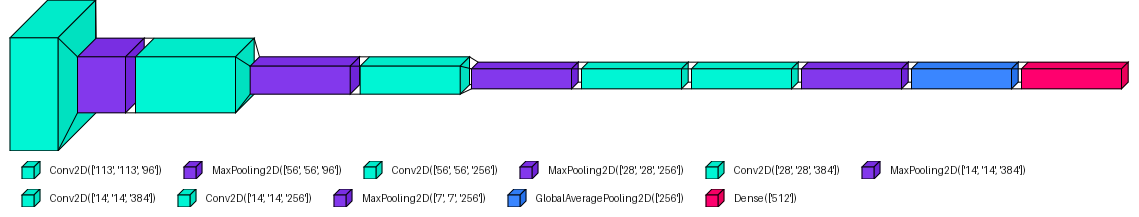

In [73]:
color_map = defaultdict(dict)
color_map[layers.Conv2D]['fill'] = '#00f5d4'
color_map[layers.MaxPooling2D]['fill'] = '#8338ec'
color_map[layers.GlobalAveragePooling2D]['fill'] = '#3a86ff'
color_map[layers.Dense]['fill'] = '#ff006e'

visual_model = get_visualizable_model(cnn_trainer.embedding_model)

img: Image = visualkeras.layered_view(
        visual_model,
        legend=True,           # Show color legend
        show_dimension=True,
        draw_volume=True,      # Draw 3D boxes
        scale_xy=1,            # Horizontal scale
        scale_z=0.5,           # Layer thickness (z-axis)
        max_z=100,             # Maximum visual thickness
        color_map=color_map,   # Apply our colors
        type_ignore=[
            layers.InputLayer,
            layers.BatchNormalization,
            layers.ReLU,
            layers.Lambda      # Ignoring the L2 Normalize Lambda layer
        ]
    )

display(img)

In [144]:
cnn_history = cnn_trainer.train(
    train_generator=train_ds,
    val_generator=val_ds,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    epochs=config['epochs'],
    callbacks=callbacks,
    verbose=1
)

15:58:54 - siamese_cnn_trainer - INFO - Starting training for 25 epochs...
15:58:54 - siamese_cnn_trainer - INFO -   - Train batches: 4851
15:58:54 - siamese_cnn_trainer - INFO -   - Val batches: 1575
Epoch 1/25
4851/4851 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 0.2480
Epoch 1: val_loss improved from inf to 0.23656, saving model to checkpoints/siamese_cnn/best.keras
4851/4851 ━━━━━━━━━━━━━━━━━━━━ 857s 175ms/step - loss: 0.2480 - val_loss: 0.2366 - learning_rate: 1.0000e-04
Epoch 2/25
4851/4851 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 0.2372
Epoch 2: val_loss improved from 0.23656 to 0.23163, saving model to checkpoints/siamese_cnn/best.keras
4851/4851 ━━━━━━━━━━━━━━━━━━━━ 846s 175ms/step - loss: 0.2372 - val_loss: 0.2316 - learning_rate: 1.0000e-04
Epoch 3/25
4851/4851 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 0.2327
Epoch 3: val_loss did not improve from 0.23163
4851/4851 ━━━━━━━━━━━━━━━━━━━━ 848s 175ms/step - loss: 0.2327 - val_loss: 0.2409 - learning_rate: 1.0000e-04
Epoch 4/25

In [53]:
cnn_history = cnn_trainer.train(
    train_generator=train_ds,
    val_generator=val_ds,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    epochs=config['epochs'],
    callbacks=callbacks,
    verbose=1
)

11:23:57 - siamese_cnn_trainer - INFO - Starting training for 20 epochs...
11:23:57 - siamese_cnn_trainer - INFO -   - Train batches: 2426
11:23:57 - siamese_cnn_trainer - INFO -   - Val batches: 1575
Epoch 1/20
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.2476
Epoch 1: val_loss improved from inf to 0.23706, saving model to checkpoints/siamese_cnn/best.keras
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 461s 182ms/step - loss: 0.2476 - val_loss: 0.2371 - learning_rate: 1.0000e-04
Epoch 2/20
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 0.2365
Epoch 2: val_loss improved from 0.23706 to 0.23237, saving model to checkpoints/siamese_cnn/best.keras
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 445s 183ms/step - loss: 0.2365 - val_loss: 0.2324 - learning_rate: 1.0000e-04
Epoch 3/20
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.2344
Epoch 3: val_loss improved from 0.23237 to 0.22939, saving model to checkpoints/siamese_cnn/best.keras
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 438s 181ms/step - loss: 0.2344 -

In [75]:
import matplotlib.pyplot as plt

def plot_training_loss(history, title="Training Loss"):
    loss = history.history["loss"]
    val_loss = history.history.get("val_loss")

    plt.figure(figsize=(8, 5))
    plt.plot(loss, label="Train Loss")
    if val_loss is not None:
        plt.plot(val_loss, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

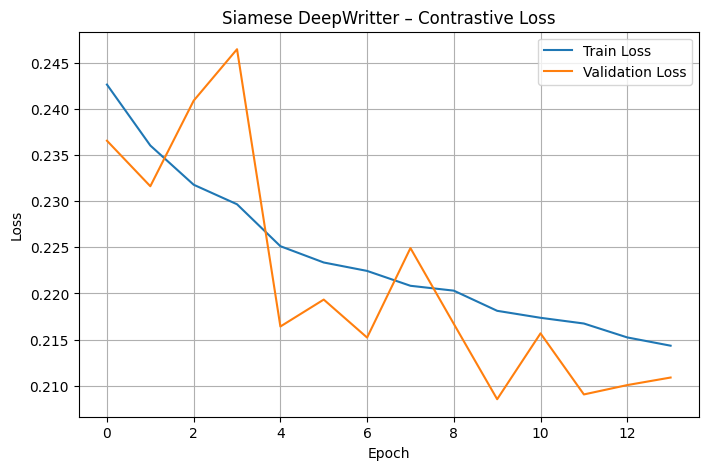

In [145]:
plot_training_loss(
    cnn_history,
    title="Siamese DeepWritter – Contrastive Loss"
)

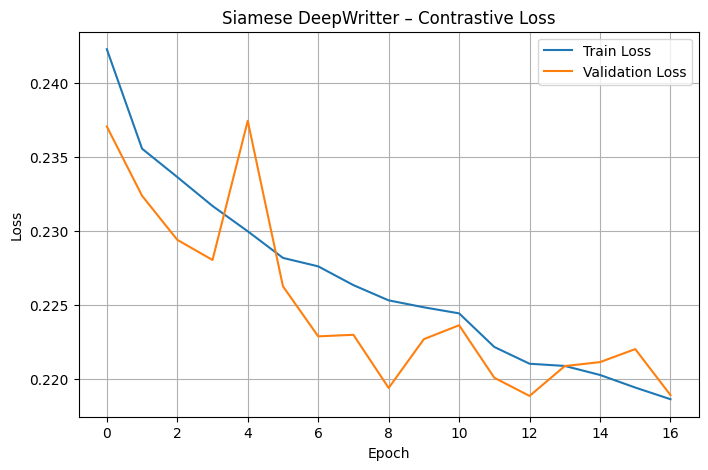

In [55]:
plot_training_loss(
    cnn_history,
    title="Siamese DeepWritter – Contrastive Loss"
)

In [146]:
cnn_trainer.save(f"./models/siamese_cnn_{current_time}.keras")

19:18:06 - siamese_cnn_trainer - INFO - Model saved to models/siamese_cnn_20260209-113711.keras


In [147]:
cnn_trainer_new = ModelTrainerFactory.create(
    backbone=DeepCNNBackbone(),
    model_name="siamese_cnn",
    model_type=config['model_type'],
    input_shape=config['input_shape'],
    embedding_dim=config['embedding_dim'],
    log_dir=f"./logs_{current_time}"
)
cnn_trainer_new.build()

19:18:21 - siamese_cnn_trainer - INFO - Model trainer initialized: siamese_cnn
19:18:21 - siamese_cnn_trainer - INFO - Input shape: (113, 113, 1)
19:18:21 - siamese_cnn_trainer - INFO - Embedding dim: 512
19:18:21 - siamese_cnn_trainer - INFO - Building models...
19:18:21 - siamese_cnn_trainer - INFO - Model built: siamese_model
19:18:21 - siamese_cnn_trainer - INFO -      - Total parameters: 3457088
19:18:21 - siamese_cnn_trainer - INFO -      - Trainable parameters: 3454336


In [148]:
cnn_trainer_new.siamese_model.load_weights(
    f"./models/siamese_cnn_{current_time}.keras"
)

In [149]:
from src.models.evaluation.verification import VerificationEvaluatorFactory

In [150]:
evaluator = VerificationEvaluatorFactory.create(
    model=cnn_trainer_new.siamese_model,
    model_name=cnn_trainer_new.model_name,
    model_type=config['model_type'],
)

In [151]:
val_res = evaluator.evaluate(
    generator=val_ds,
    steps=val_steps,
    threshold_strategy="eer"
)

19:20:59 - siamese_cnn_evaluator - INFO - Verification evaluation completed
19:20:59 - siamese_cnn_evaluator - INFO -   Threshold: 0.4872
19:20:59 - siamese_cnn_evaluator - INFO -   Accuracy:  0.6622
19:20:59 - siamese_cnn_evaluator - INFO -   AUC:       0.7317
19:20:59 - siamese_cnn_evaluator - INFO -   Precision: 0.6622
19:20:59 - siamese_cnn_evaluator - INFO -   Recall:    0.6622
19:20:59 - siamese_cnn_evaluator - INFO -   F1-score:  0.6622


In [152]:
threshold = val_res['threshold']
logger.info(f"Optimal threshold: {threshold:.4f}")

INFO - Optimal threshold: 0.4872


In [153]:
test_ds, test_steps = test_pair_gen.to_dataset()

In [154]:
test_res = evaluator.evaluate(
    generator=test_ds,
    steps=test_steps,
    distance_threshold=threshold
)

19:22:35 - siamese_cnn_evaluator - INFO - Verification evaluation completed
19:22:35 - siamese_cnn_evaluator - INFO -   Threshold: 0.4872
19:22:35 - siamese_cnn_evaluator - INFO -   Accuracy:  0.7672
19:22:35 - siamese_cnn_evaluator - INFO -   AUC:       0.8518
19:22:35 - siamese_cnn_evaluator - INFO -   Precision: 0.7267
19:22:35 - siamese_cnn_evaluator - INFO -   Recall:    0.8565
19:22:35 - siamese_cnn_evaluator - INFO -   F1-score:  0.7863


In [155]:
distances = test_res['distances']
y_true = test_res['y_true']

In [156]:
from scipy.stats import ks_2samp

In [157]:
def compute_distance_statistics(same_author_distances: np.ndarray, diff_author_distances: np.ndarray) -> dict[str, any]:
    same_stats = {
        "mean": float(same_author_distances.mean()),
        "median": float(np.median(same_author_distances)),
        "std": float(same_author_distances.std()),
        "min": float(same_author_distances.min()),
        "max": float(same_author_distances.max()),
        "count": len(same_author_distances)
    }

    diff_stats = {
        "mean": float(diff_author_distances.mean()),
        "median": float(np.median(diff_author_distances)),
        "std": float(diff_author_distances.std()),
        "min": float(diff_author_distances.min()),
        "max": float(diff_author_distances.max()),
        "count": len(diff_author_distances)
    }

    separation = diff_stats["mean"] - same_stats["mean"]
    separation_ratio = diff_stats["mean"] / (same_stats["mean"] + 1e-8)

    ks_stat, ks_pvalue = ks_2samp(same_author_distances, diff_author_distances)

    overlap_start = max(same_stats["min"], diff_stats["min"])
    overlap_end = min(same_stats["max"], diff_stats["max"])
    has_overlap = overlap_end > overlap_start
    overlap_width = overlap_end - overlap_start if has_overlap else 0.0

    return {
        "same_author": same_stats,
        "diff_author": diff_stats,
        "separation": separation,
        "separation_ratio": separation_ratio,
        "ks_statistic": float(ks_stat),
        "ks_pvalue": float(ks_pvalue),
        "has_overlap": has_overlap,
        "overlap_width": float(overlap_width),
        "overlap_start": float(overlap_start) if has_overlap else None,
        "overlap_end": float(overlap_end) if has_overlap else None,
    }

In [158]:
def compute_threshold_metrics(same_author_distances: np.ndarray, diff_author_distances: np.ndarray, threshold: float) -> dict[str, any]:
    same_bellow = (same_author_distances < threshold).sum()
    same_total = len(same_author_distances)
    true_positive_rate = same_bellow / same_total if same_total > 0 else 0.0

    diff_above = (diff_author_distances >= threshold).sum()
    diff_total = len(diff_author_distances)
    true_negative_rate = diff_above / diff_total if diff_total > 0 else 0.0

    return {
        "threshold": float(threshold),
        "same_below_threshold": int(same_bellow),
        "same_total": int(same_total),
        "true_positive_rate": float(true_positive_rate),
        "diff_above_threshold": int(diff_above),
        "diff_total": int(diff_total),
        "true_negative_rate": float(true_negative_rate),
    }

In [159]:
def log_distance_statistics(logger: LoggerFactory, stats: dict[str, any]) -> None:
    logger.info("=" * 60)
    logger.info("DISTANCE DISTRIBUTION ANALYSIS")
    logger.info("=" * 60)

    same = stats["same_author"]
    logger.info(f"\n📊 Same Author Pairs (n={same['count']}):")
    logger.info(f"   Mean:   {same['mean']:.4f}")
    logger.info(f"   Median: {same['median']:.4f}")
    logger.info(f"   Std:    {same['std']:.4f}")
    logger.info(f"   Range:  [{same['min']:.4f}, {same['max']:.4f}]")

    diff = stats["diff_author"]
    logger.info(f"\n📊 Different Author Pairs (n={diff['count']}):")
    logger.info(f"   Mean:   {diff['mean']:.4f}")
    logger.info(f"   Median: {diff['median']:.4f}")
    logger.info(f"   Std:    {diff['std']:.4f}")
    logger.info(f"   Range:  [{diff['min']:.4f}, {diff['max']:.4f}]")

    logger.info(f"\n🎯 Separation Metrics:")
    logger.info(f"   Mean separation: {stats['separation']:.4f}")
    logger.info(f"   Separation ratio: {stats['separation_ratio']:.2f}x")
    logger.info(f"   KS statistic: {stats['ks_statistic']:.4f} (higher is better, max=1.0)")
    logger.info(f"   KS p-value: {stats['ks_pvalue']:.2e} (should be < 0.05)")

    if stats["has_overlap"]:
        logger.info(f"\n⚠️  Overlap detected:")
        logger.info(f"   Range: [{stats['overlap_start']:.4f}, {stats['overlap_end']:.4f}]")
        logger.info(f"   Width: {stats['overlap_width']:.4f}")
    else:
        logger.info(f"\n✅ No overlap (perfect separation!)")

In [168]:
def log_threshold_metrics(logger: LoggerFactory, metrics: dict[str, any]) -> None:
    logger.info(f"\n🎚️  Threshold Analysis (threshold={metrics['threshold']:.4f}):")
    logger.info(
        f"  Same author pairs below threshold: "
        f"{metrics['same_below_threshold']}/{metrics['same_total']} "
        f"({100 * metrics['true_positive_rate']:.1f}%)"
    )
    logger.info(
        f"  Diff author pairs above threshold: "
        f"{metrics['diff_above_threshold']}/{metrics['diff_total']} "
        f"({100 * metrics['true_negative_rate']:.1f}%)"
    )
    logger.info("=" * 60)

In [161]:
def plot_distance_histogram(
    same_author_distances: np.ndarray,
    diff_author_distances: np.ndarray,
    threshold: float,
    ax: plt.Axes | None = None,
    title: str = "Distance Distribution"
) -> plt.Axes:
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    ax.hist(
        same_author_distances,
        bins=50,
        alpha=0.6,
        density=True,
        label=f"Same author (n={len(same_author_distances)})",
        color="#2ecc71",
        edgecolor="black",
        linewidth=0.5
    )

    ax.hist(
        diff_author_distances,
        bins=50,
        alpha=0.6,
        density=True,
        label=f"Different authors (n={len(diff_author_distances)})",
        color="#e74c3c",
        edgecolor="black",
        linewidth=0.5
    )

    ax.axvline(
        threshold,
        color="black",
        linestyle="--",
        linewidth=2,
        label=f"Threshold = {threshold:.4f}"
    )

    same_mean = same_author_distances.mean()
    diff_mean = diff_author_distances.mean()

    ax.axvline(
        same_mean,
        color="#27ae60",
        linestyle=":",
        linewidth=1.5,
        alpha=0.7,
        label=f'Same mean = {same_mean:.4f}'
    )

    ax.axvline(
        diff_mean,
        color="#c0392b",
        linestyle=":",
        linewidth=1.5,
        alpha=0.7,
        label=f'Diff mean = {diff_mean:.4f}'
    )

    ax.set_xlabel("Euclidean Distance", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3, linestyle="--")

    return ax

In [162]:
def plot_distance_boxplot(
    same_author_distances: np.ndarray,
    diff_author_distances: np.ndarray,
    threshold: float,
    ax: plt.Axes | None = None,
    title: str = "Distance Distribution (Box Plot)"
) -> plt.Axes:
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    box_data = [same_author_distances, diff_author_distances]
    bp = ax.boxplot(
        box_data,
        labels=["Same\nAuthor", "Different\nAuthors"],
        patch_artist=True,
        widths=0.6
    )

    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')

    ax.axhline(
        threshold,
        color="black",
        linestyle="--",
        linewidth=2,
        label=f'Threshold = {threshold:.4f}'
    )

    ax.set_ylabel("Euclidean Distance", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle="--", axis="y")

    return ax

In [164]:
def plot_distance_analysis(
    same_author_distances: np.ndarray,
    diff_author_distances: np.ndarray,
    threshold: float,
) -> tuple[plt.Figure, tuple[plt.Axes, plt.Axes]]:
    separation = diff_author_distances.mean() - same_author_distances.mean()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    plot_distance_histogram(
        same_author_distances,
        diff_author_distances,
        threshold,
        ax=ax1,
        title=f'Distance Distribution (Separation: {separation:.4f})'
    )

    plot_distance_boxplot(
        same_author_distances,
        diff_author_distances,
        threshold,
        ax=ax2
    )

    return fig, (ax1, ax2)

In [165]:
def analyze_distance_distribution(
    distances: np.ndarray,
    y_true: np.ndarray,
    threshold: float,
    logger: LoggerFactory,
    show_plot: bool = True,
) -> dict[str, any]:

    same_author_distances = distances[y_true == 1]
    diff_author_distances = distances[y_true == 0]

    stats = compute_distance_statistics(same_author_distances, diff_author_distances)
    threshold_metrics = compute_threshold_metrics(same_author_distances, diff_author_distances, threshold)

    log_distance_statistics(logger, stats)
    log_threshold_metrics(logger, threshold_metrics)

    fig, axes = plot_distance_analysis(same_author_distances, diff_author_distances, threshold)

    if show_plot: plt.show()
    else: plt.close(fig)

    return {
        **stats,
        "threshold_metrics": threshold_metrics
    }

INFO - ============================================================
INFO - DISTANCE DISTRIBUTION ANALYSIS
INFO - ============================================================
INFO - 
📊 Same Author Pairs (n=6264):
INFO -    Mean:   0.3492
INFO -    Median: 0.3360
INFO -    Std:    0.1262
INFO -    Range:  [0.0629, 0.8820]
INFO - 
📊 Different Author Pairs (n=6264):
INFO -    Mean:   0.5927
INFO -    Median: 0.5824
INFO -    Std:    0.1908
INFO -    Range:  [0.1325, 1.1054]
INFO - 
🎯 Separation Metrics:
INFO -    Mean separation: 0.2435
INFO -    Separation ratio: 1.70x
INFO -    KS statistic: 0.5447 (higher is better, max=1.0)
INFO -    KS p-value: 0.00e+00 (should be < 0.05)
INFO - 
⚠️  Overlap detected:
INFO -    Range: [0.1325, 0.8820]
INFO -    Width: 0.7495
INFO - 
🎚️  Threshold Analysis (threshold=0.4872):
INFO -   Same author pairs below threshold: 5365/6264 (85.6%)
INFO -   Diff author pairs above threshold: 4246/6264 (67.8%)
INFO - ================================================

/tmp/ipython-input-2604019710.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


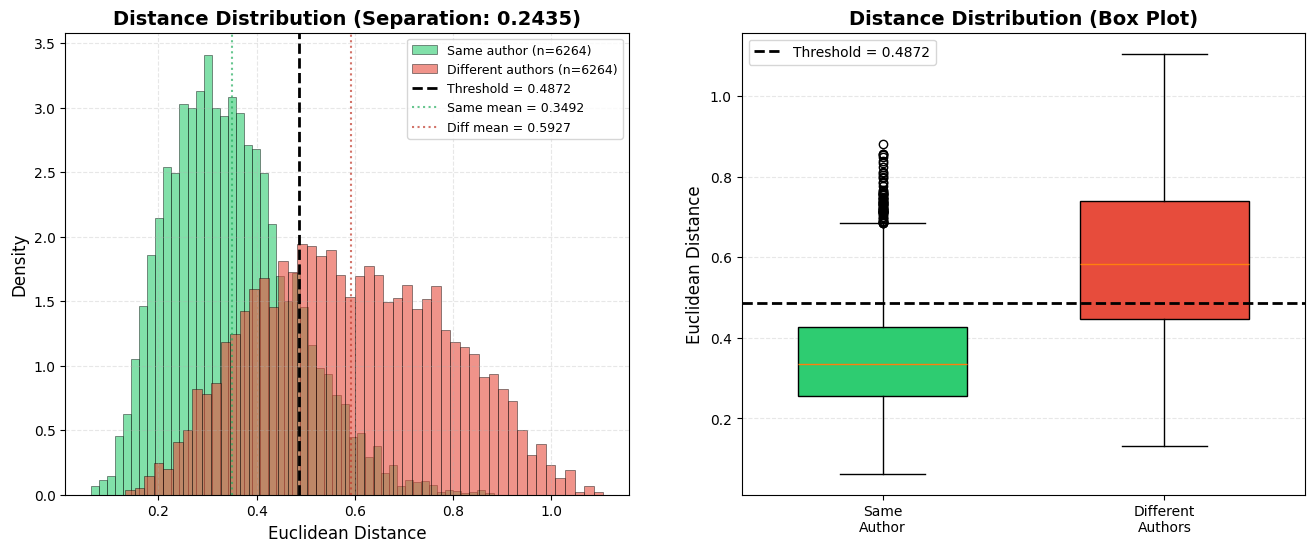

In [169]:
analysis = analyze_distance_distribution(
    distances=test_res["distances"],
    y_true=test_res["y_true"],
    threshold=threshold,
    logger=logger,
    show_plot=True
)

In [170]:
from src.models.evaluation.identification import (
    IdentificationEvaluator,
    NearestMeanStrategy,
    VotingStrategy,
    MeanGalleryBuilder,
    FullGalleryBuilder,
    IdentificationFactory
)

In [171]:
id_eval = IdentificationFactory.create(
    embedding_model=cnn_trainer_new.embedding_model,
    strategy=NearestMeanStrategy(),
    gallery_builder=MeanGalleryBuilder(),
    mode="closed-set",
    seed=config['seed']
)

In [172]:
from src.datasets import DataGenerator

In [173]:
test_gen = DataGenerator(
    data=subset.splits['test'],
    target_size=config['input_shape'][:2],
    batch_size=config['batch_size']['test'],
    use_augmentation=False,
    shuffle=False,
    seed=config['seed']
)

In [174]:
test_ds, test_steps = test_gen.to_dataset()

In [175]:
results = id_eval.evaluate(
    dataset=test_ds,
    steps=test_steps
)

19:28:24 - embedding_model_identification - INFO - Starting identification evaluation
19:28:24 - embedding_model_identification - INFO -   Strategy: NearestMeanStrategy
19:28:24 - embedding_model_identification - INFO -   Gallery ratio: 0.5
19:28:24 - embedding_model_identification - INFO -   Min probe samples: 2
19:28:24 - embedding_model_identification - INFO - Extracting embeddings from 783 batches...
19:28:44 - embedding_model_identification - INFO - Extracted 12519 embeddings from 100 unique authors
19:28:44 - embedding_model_identification - INFO - Closed-set identification evaluation completed
19:28:44 - embedding_model_identification - INFO -   Num authors evaluated: 100
19:28:44 - embedding_model_identification - INFO -   Accuracy: 0.9900


In [98]:
results.keys()

dict_keys(['accuracy', 'num_authors', 'y_true', 'y_pred', 'details'])

In [99]:
results['details'][0].keys()

dict_keys(['true_author_id', 'pred_author_id', 'scores', 'min_distance', 'confidence'])

In [176]:
import pandas as pd

def identification_results_to_df(res: dict) -> pd.DataFrame:
    """
    Convert identification results to a per-author DataFrame.
    """
    df = pd.DataFrame(res["details"])

    if "scores" in df.columns:
      df = df.drop(columns=["scores"])

    # Ensure proper dtypes
    df["true_author_id"] = df["true_author_id"].astype(int)
    df["pred_author_id"] = df["pred_author_id"].astype(int)
    df["min_distance"] = df["min_distance"].astype(float)
    df["confidence"] = df["confidence"].astype(float)

    return df

In [177]:
def extract_identification_summary(res: dict) -> dict[str, float | int]:
    """
    Extract high-level identification metrics.
    """
    return {
        "accuracy": res["accuracy"],
        "num_authors": res["num_authors"],
        "y_true": res["y_true"],
        "y_pred": res["y_pred"],
    }

In [178]:
res = identification_results_to_df(results)
summary = extract_identification_summary(results)

In [179]:
logger.info(f"Identification summary: {summary['accuracy']} - {summary['num_authors']}")

INFO - Identification summary: 0.99 - 100


In [180]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    title: str,
    normalize: bool = True
) -> None:
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(
        y_true,
        y_pred,
        normalize='true' if normalize else None,
    )
    fig, ax = plt.subplots(figsize=(8, 8))
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax, ax=ax)

    ax.set_title(f"{title} (Acc: {acc:.2%})", fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    plt.tight_layout()
    plt.show()

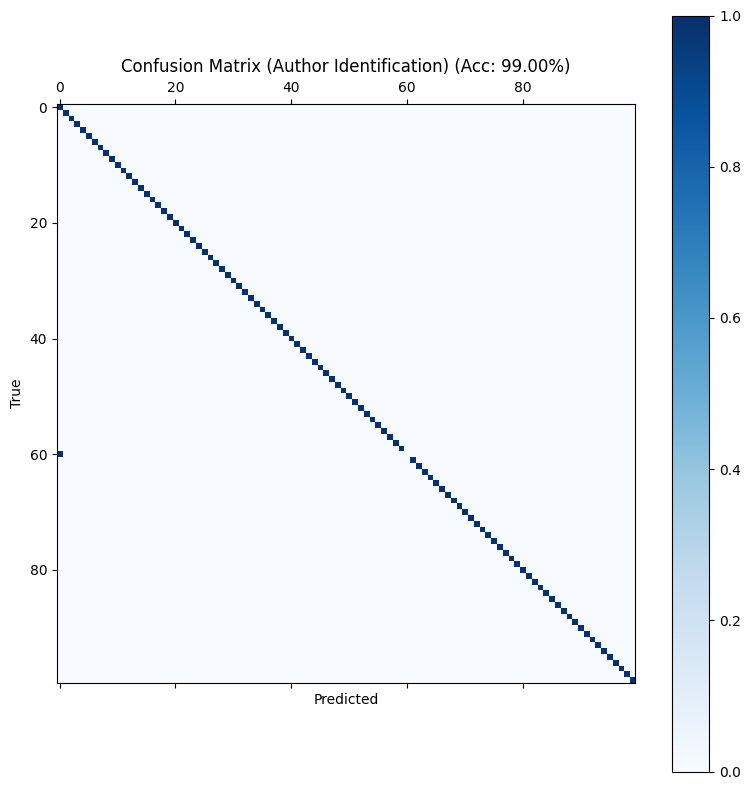

In [181]:
plot_confusion_matrix(
    summary["y_true"],
    summary["y_pred"],
    title="Confusion Matrix (Author Identification)",
    normalize=True,
)

In [182]:
res

,true_author_id,pred_author_id,min_distance,confidence
0,0,0,0.168480,0.804052
1,1,1,0.177541,0.796237
2,2,2,0.169879,0.811962
3,3,3,0.282561,0.626738
4,4,4,0.281992,0.649287
...,...,...,...,...
95,95,95,0.240096,0.730579
96,96,96,0.251217,0.696537
97,97,97,0.203031,0.774793
98,98,98,0.256460,0.678436


In [183]:
evaluator_voting = IdentificationFactory.create(
    embedding_model=cnn_trainer_new.embedding_model,
    strategy=VotingStrategy(distance_threshold=threshold),
    gallery_builder=FullGalleryBuilder(),
    mode="closed-set",
    seed=config['seed']
)

In [184]:
voting_results = evaluator_voting.evaluate(
    dataset=test_ds,
    steps=test_steps
)

19:29:38 - embedding_model_identification - INFO - Starting identification evaluation
19:29:38 - embedding_model_identification - INFO -   Strategy: VotingStrategy
19:29:38 - embedding_model_identification - INFO -   Gallery ratio: 0.5
19:29:38 - embedding_model_identification - INFO -   Min probe samples: 2
19:29:38 - embedding_model_identification - INFO - Extracting embeddings from 783 batches...
19:29:58 - embedding_model_identification - INFO - Extracted 12519 embeddings from 100 unique authors
19:30:27 - embedding_model_identification - INFO - Closed-set identification evaluation completed
19:30:27 - embedding_model_identification - INFO -   Num authors evaluated: 100
19:30:27 - embedding_model_identification - INFO -   Accuracy: 0.4000


In [185]:
import pandas as pd

def voting_results_to_df(res: dict) -> pd.DataFrame:
    """
    Convert identification results to a per-author DataFrame.
    """
    df = pd.DataFrame(res["details"])

    if "scores" in df.columns:
      df = df.drop(columns=["scores"])

    # Ensure proper dtypes
    df["true_author_id"] = df["true_author_id"].astype(int)
    df["pred_author_id"] = df["pred_author_id"].astype(int)
    df["confidence"] = df["confidence"].astype(float)

    return df

In [109]:
voting_results.keys()

dict_keys(['accuracy', 'num_authors', 'y_true', 'y_pred', 'details'])

In [110]:
voting_results['details'][0].keys()

dict_keys(['true_author_id', 'pred_author_id', 'scores', 'confidence'])

In [186]:
res_voting = voting_results_to_df(voting_results)
summary_voting = extract_identification_summary(voting_results)

In [187]:
logger.info(f"Identification by voting summary: {summary_voting['accuracy']} - {summary_voting['num_authors']}")

INFO - Identification by voting summary: 0.4 - 100


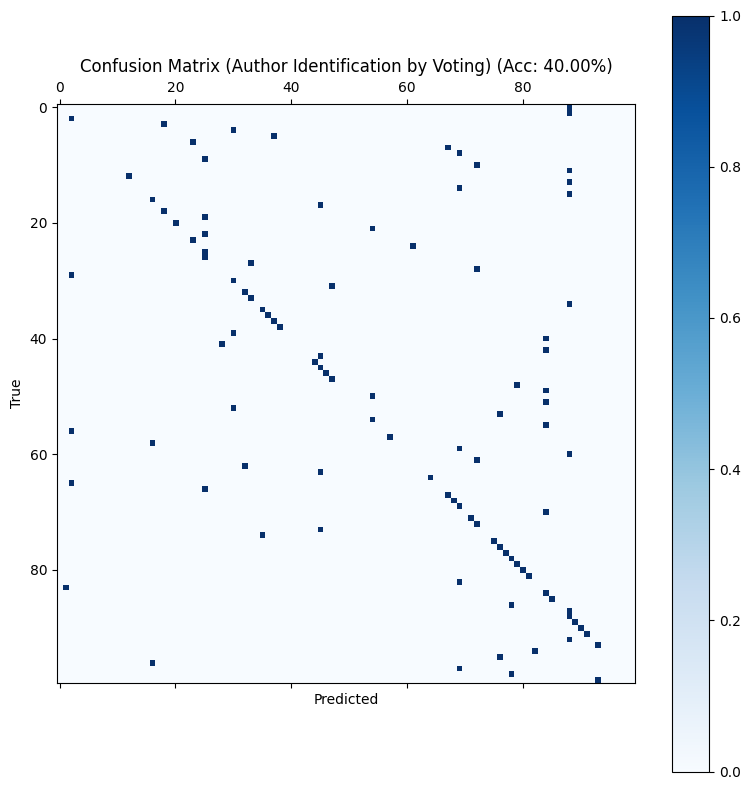

In [188]:
plot_confusion_matrix(
    summary_voting["y_true"],
    summary_voting["y_pred"],
    title="Confusion Matrix (Author Identification by Voting)",
    normalize=True,
)

In [189]:
res_voting

,true_author_id,pred_author_id,confidence
0,0,88,0.600741
1,1,88,0.627742
2,2,2,0.636818
3,3,18,0.516029
4,4,30,0.503594
...,...,...,...
95,95,76,0.550517
96,96,16,0.530323
97,97,69,0.637538
98,98,78,0.556000


INFO - Positive pairs - mean: 0.3492, std: 0.1262
INFO - Negative pairs - mean: 0.5927, std: 0.1908
INFO - Separation: 0.2435


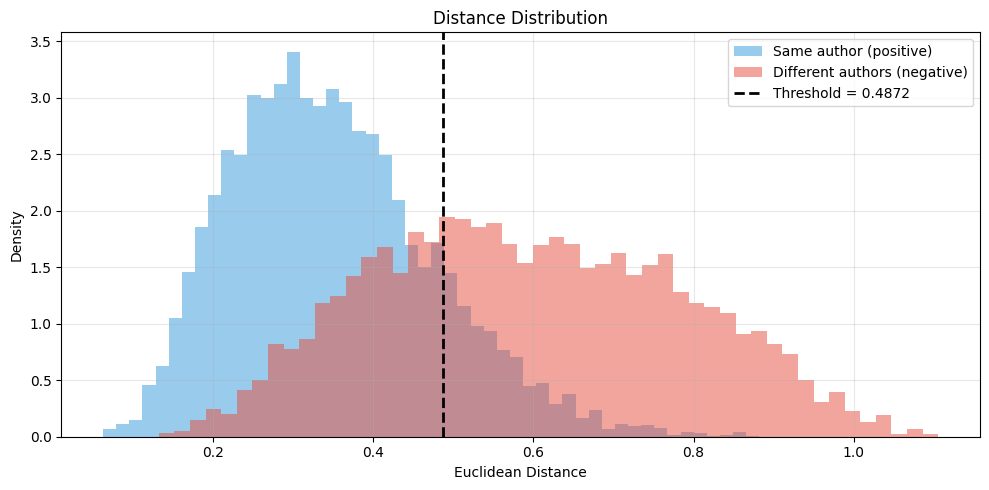

In [190]:
import matplotlib.pyplot as plt

pos_distances = distances[y_true == 1]
neg_distances = distances[y_true == 0]

logger.info(f"Positive pairs - mean: {pos_distances.mean():.4f}, std: {pos_distances.std():.4f}")
logger.info(f"Negative pairs - mean: {neg_distances.mean():.4f}, std: {neg_distances.std():.4f}")
logger.info(f"Separation: {neg_distances.mean() - pos_distances.mean():.4f}")

# Plot histograma
plt.figure(figsize=(10, 5))
plt.hist(pos_distances, bins=50, alpha=0.5, density=True, label='Same author (positive)', color='#3498db')
plt.hist(neg_distances, bins=50, alpha=0.5, density=True, label='Different authors (negative)', color='#e74c3c')
plt.axvline(x=threshold, color='k', linestyle='--', linewidth=2,
            label=f'Threshold = {threshold:.4f}')
plt.xlabel('Euclidean Distance')
plt.ylabel('Density')
plt.legend()
plt.title('Distance Distribution')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [214]:
unseen_subset = subset_builder.build(
    authors_range=range(100, 407),
    show_progress_bar=True,
)

19:56:17 - ZarrSerializer - INFO - ======================================================================
19:56:17 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
19:56:17 - ZarrSerializer - INFO - ======================================================================
19:56:17 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
19:56:17 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
19:56:17 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
19:56:17 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
19:56:17 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
19:56:17 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
19:56:17 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
19:56:17 - ZarrSerializer - INFO - ======================================================================
19:56:17 - ZarrSerializer - INF

Loading train: 100%|██████████| 307/307 [01:36<00:00,  3.17it/s]


19:58:03 - ZarrSerializer - INFO - ======================================================================
19:58:03 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
19:58:03 - ZarrSerializer - INFO - ======================================================================
19:58:03 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
19:58:03 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
19:58:03 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
19:58:03 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
19:58:03 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
19:58:03 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
19:58:03 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
19:58:03 - ZarrSerializer - INFO - ======================================================================
19:58:03 - ZarrSerializer - INF

Loading validation: 100%|██████████| 307/307 [00:13<00:00, 22.50it/s]


19:58:19 - ZarrSerializer - INFO - ======================================================================
19:58:19 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
19:58:19 - ZarrSerializer - INFO - ======================================================================
19:58:19 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
19:58:19 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
19:58:19 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
19:58:19 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
19:58:19 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
19:58:19 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
19:58:19 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
19:58:19 - ZarrSerializer - INFO - ======================================================================
19:58:19 - ZarrSerializer - INF

Loading test: 100%|██████████| 307/307 [00:03<00:00, 85.13it/s]


In [215]:
unseen_test_pair_gen = PairGenerator(
    data=unseen_subset.splits['test'],
    batch_size=config['batch_size']['test'],
    target_size=config['input_shape'][:2],
    use_augmentation=False,
    shuffle=False,
    seed=config['seed']
)

In [216]:
test_ds, test_steps = unseen_test_pair_gen.to_dataset()

In [217]:
unseen_test_results = evaluator.evaluate(
    generator=test_ds,
    steps=test_steps,
    distance_threshold=threshold
)

20:02:05 - siamese_cnn_evaluator - INFO - Verification evaluation completed
20:02:05 - siamese_cnn_evaluator - INFO -   Threshold: 0.4872
20:02:05 - siamese_cnn_evaluator - INFO -   Accuracy:  0.7559
20:02:05 - siamese_cnn_evaluator - INFO -   AUC:       0.8363
20:02:05 - siamese_cnn_evaluator - INFO -   Precision: 0.7159
20:02:05 - siamese_cnn_evaluator - INFO -   Recall:    0.8487
20:02:05 - siamese_cnn_evaluator - INFO -   F1-score:  0.7766


INFO - ============================================================
INFO - DISTANCE DISTRIBUTION ANALYSIS
INFO - ============================================================
INFO - 
📊 Same Author Pairs (n=19280):
INFO -    Mean:   0.3489
INFO -    Median: 0.3325
INFO -    Std:    0.1319
INFO -    Range:  [0.0350, 1.0014]
INFO - 
📊 Different Author Pairs (n=19280):
INFO -    Mean:   0.5873
INFO -    Median: 0.5839
INFO -    Std:    0.1967
INFO -    Range:  [0.1095, 1.1375]
INFO - 
🎯 Separation Metrics:
INFO -    Mean separation: 0.2383
INFO -    Separation ratio: 1.68x
INFO -    KS statistic: 0.5151 (higher is better, max=1.0)
INFO -    KS p-value: 0.00e+00 (should be < 0.05)
INFO - 
⚠️  Overlap detected:
INFO -    Range: [0.1095, 1.0014]
INFO -    Width: 0.8919
INFO - 
🎚️  Threshold Analysis (threshold=0.4872):
INFO -   Same author pairs below threshold: 16362/19280 (84.9%)
INFO -   Diff author pairs above threshold: 12787/19280 (66.3%)
INFO - ==========================================

/tmp/ipython-input-2604019710.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


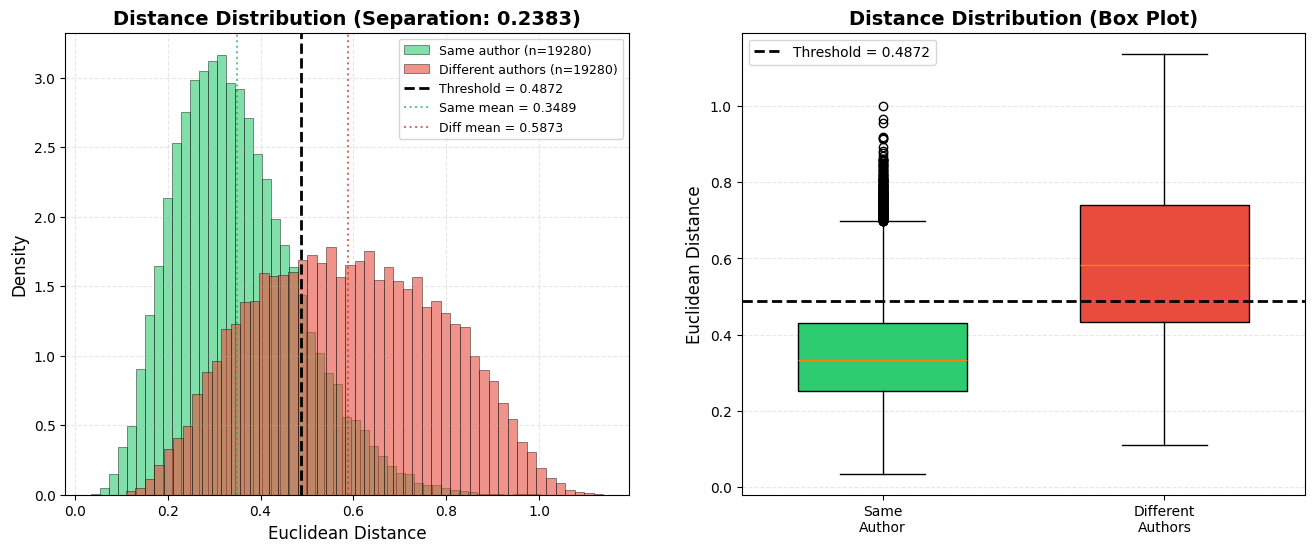

In [218]:
unseen_analysis = analyze_distance_distribution(
    distances=unseen_test_results["distances"],
    y_true=unseen_test_results["y_true"],
    threshold=threshold,
    logger=logger,
    show_plot=True
)

In [219]:
unseen_id_eval = IdentificationFactory.create(
    embedding_model=cnn_trainer_new.embedding_model,
    strategy=NearestMeanStrategy(),
    gallery_builder=MeanGalleryBuilder(),
    mode="open-set",
    seed=config['seed']
)

In [220]:
unseen_test_gen = DataGenerator(
    data=unseen_subset.splits['test'],
    target_size=config['input_shape'][:2],
    batch_size=config['batch_size']['test'],
    use_augmentation=False,
    shuffle=False,
    seed=config['seed']
)

In [221]:
unseen_test_ds, unseen_test_steps = unseen_test_gen.to_dataset()

In [222]:
unseen_results = unseen_id_eval.evaluate(
    dataset=unseen_test_ds,
    steps=unseen_test_steps
)

20:02:05 - embedding_model_identification - INFO - Starting identification evaluation
20:02:05 - embedding_model_identification - INFO -   Strategy: NearestMeanStrategy
20:02:05 - embedding_model_identification - INFO -   Gallery ratio: 0.5
20:02:05 - embedding_model_identification - INFO -   Min probe samples: 2
20:02:05 - embedding_model_identification - INFO - Extracting embeddings from 2410 batches...
20:03:08 - embedding_model_identification - INFO - Extracted 38548 embeddings from 307 unique authors
20:03:18 - embedding_model_identification - INFO - Open-set identification evaluation completed
20:03:18 - embedding_model_identification - INFO -   Num known authors: 307
20:03:18 - embedding_model_identification - INFO -   Num unknown authors: 0
20:03:18 - embedding_model_identification - INFO -   Detection rate: 0.9349
20:03:18 - embedding_model_identification - INFO -   False alarm rate: 0.0000
20:03:18 - embedding_model_identification - INFO -   Rejection rate: 0.0000


In [223]:
unseen_results.keys()

dict_keys(['detection_rate', 'false_alarm_rate', 'rejection_rate', 'closed_set_accuracy', 'num_known', 'num_unknown', 'y_true', 'y_pred', 'y_true_binary', 'y_pred_binary', 'details'])

In [224]:
unseen_res = identification_results_to_df(unseen_results)

In [225]:
logger.info(f"Identification summary: {unseen_results['closed_set_accuracy']}")

INFO - Identification summary: 0.9348534201954397


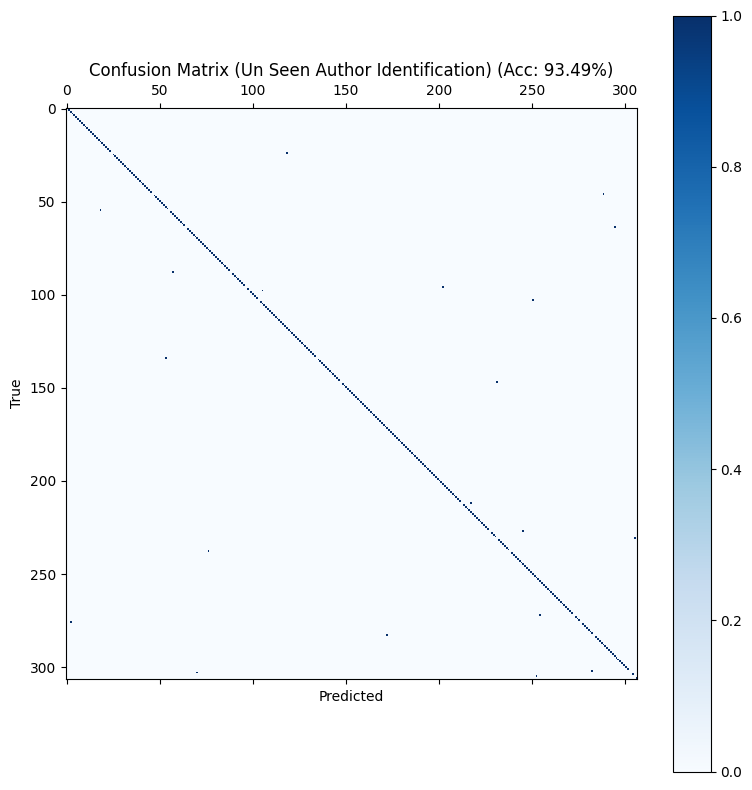

In [226]:
plot_confusion_matrix(
    unseen_results["y_true"],
    unseen_results["y_pred"],
    title="Confusion Matrix (Un Seen Author Identification)",
    normalize=True,
)

In [227]:
unseen_res

,true_author_id,is_known,was_rejected,pred_author_id,min_distance,confidence
0,0,True,False,0,0.239921,0.737765
1,1,True,False,1,0.271902,0.681779
2,2,True,False,2,0.278927,0.676915
3,3,True,False,3,0.282045,0.623934
4,4,True,False,4,0.262100,0.690549
...,...,...,...,...,...,...
302,302,True,False,282,0.284711,0.654905
303,303,True,False,70,0.232354,0.745956
304,304,True,False,304,0.141530,0.838218
305,305,True,False,252,0.282639,0.648506


In [228]:
unseen_evaluator_voting = IdentificationFactory.create(
    embedding_model=cnn_trainer_new.embedding_model,
    strategy=VotingStrategy(distance_threshold=threshold),
    gallery_builder=FullGalleryBuilder(),
    mode="open-set",
    seed=config['seed']
)

In [ ]:
unseen_voting_results = unseen_evaluator_voting.evaluate(
    dataset=unseen_test_ds,
    steps=unseen_test_steps
)

20:03:19 - embedding_model_identification - INFO - Starting identification evaluation
20:03:19 - embedding_model_identification - INFO -   Strategy: VotingStrategy
20:03:19 - embedding_model_identification - INFO -   Gallery ratio: 0.5
20:03:19 - embedding_model_identification - INFO -   Min probe samples: 2
20:03:19 - embedding_model_identification - INFO - Extracting embeddings from 2410 batches...
20:04:20 - embedding_model_identification - INFO - Extracted 38548 embeddings from 307 unique authors


In [ ]:
unseen_voting_results.keys()

In [ ]:
unseen_res_voting = voting_results_to_df(unseen_voting_results)

In [ ]:
logger.info(f"Identification summary: {unseen_voting_results['closed_set_accuracy']}")

In [ ]:
plot_confusion_matrix(
    unseen_voting_results["y_true"],
    unseen_voting_results["y_pred"],
    title="Confusion Matrix (Un Seen Author Identification by Voting)",
    normalize=True,
)

In [ ]:
unseen_res_voting